# Assignment 2: Data Wrangling and Exploratory Analysis

## Applying NumPy and Pandas to a Real Dataset

### Dataset

**Dataset:** Loan Prediction Dataset

**Domain:** Banking and Financial Services

**Source:** Loan Prediction Dataset repository on GitHub

**Source URL:**  
https://github.com/shrikant-temburwar/Loan-Prediction-Dataset

**Dataset URL:**  
https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv

### Why I chose this dataset

I chose the Loan Prediction dataset because it represents a real-world banking and lending problem. It contains information about loan applicants, including their income, education, employment status, credit history, loan amount, property area, and loan approval status.

The dataset contains both numerical and categorical variables and includes missing values, making it suitable for practicing data inspection, cleaning, feature engineering, GroupBy aggregation, merging, NumPy computation, and exploratory visualization.

For this analysis, I will investigate:

> **What applicant and financial characteristics are associated with successful loan approval?**

### License / Usage

The dataset is accessed from the publicly available GitHub repository listed above and is being used for educational and analytical purposes. The original source is retained for attribution.

## Task 1: Dataset Selection and Schema Report

The first step is to load the dataset and understand its structure before making any cleaning decisions.

In [1]:
#  Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1.1 Load Dataset

# Load the Loan Prediction dataset from the public GitHub repository

url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"

df = pd.read_csv(url)

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
# 1.2 Dataset Shapes

# The shape shows the number of rows and columns in the dataset.

print("Dataset shape:", df.shape)

Dataset shape: (614, 13)


In [6]:
# 1.3 Column Names

# The column names help identify the variables available for analysis.

print("Column names:")
print(df.columns.tolist())

Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [7]:
# 1.4 Data Types

# Checking data types helps identify variables that may need to be converted before analysis.

print("Data types:")
print(df.dtypes)

Data types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [8]:
# 1.5 Missing Values

#Before cleaning the dataset, I will identify which columns contain missing values and determine how they should be handled.

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [9]:
# 1.6 Unique Values

#Unique-value counts help identify categorical variables and understand the variety of values in each column.

print("Unique values per column:")
print(df.nunique())

Unique values per column:


Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64


In [10]:
# 1.7 Dataset Information

#The `info()` method provides a compact overview of the dataset, including the number of non-null values and data types.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


## Task 2: Data Cleaning

Based on the schema report from Task 1, I will clean the dataset by handling missing values, correcting data types where necessary, and checking for duplicate rows.

The cleaning decisions will be made deliberately based on the characteristics of each variable rather than applying the same method to every column.

In [11]:
# 2.1 Create a Copy of the Dataset

# I will create a copy of the original dataset so that the raw data remains unchanged and can be compared with the cleaned version.

# Create a copy of the original dataset for cleaning

df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaning dataframe shape:", df_clean.shape)

Original shape: (614, 13)
Cleaning dataframe shape: (614, 13)


In [12]:
# 2.2 Inspect Missing Values

#The dataset contains missing values in some applicant and loan-related variables.
# I will first identify the columns containing missing values and their counts before deciding how to handle them.

# Display columns containing missing values
missing = df_clean.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [13]:
# 2.3 Handle Missing Categorical Values

#For categorical variables, I will use the mode (most frequent value) to fill missing values.
#This approach preserves the existing categories and avoids unnecessarily removing applicant records.

# Fill missing values in categorical columns using the most frequent value
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

print("Missing categorical values handled.")

Missing categorical values handled.


In [14]:
# 2.4 Handle Missing Numerical Values

#For numerical variables, I will use the median to fill missing values.
#The median is appropriate here because financial variables such as income and loan amount can contain unusually large values, and the median is less sensitive to extreme values than the mean.

# Fill missing numerical values using the median
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [15]:
# 2.5 Verify Missing Values After Cleaning

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [16]:
# 2.6 Check and Fix Data Types

#The `Dependents` column contains the value `"3+"`, which is categorical text even though the variable represents a number of dependents.
#I will convert `"3+"` to `3` and then convert the column to a numeric data type.


df_clean["Dependents"] = df_clean["Dependents"].replace("3+", "3")
df_clean["Dependents"] = pd.to_numeric(df_clean["Dependents"])

print(df_clean["Dependents"].dtype)

int64


In [17]:
# 2.7 Check for Duplicate Rows

#Duplicate records can affect analysis by giving some observations more weight than others.
#I will check for duplicates before deciding whether any rows need to be removed.

# Count duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [18]:
# 2.8 Remove Duplicate Rows if Necessary

#If duplicate rows are found, they will be removed because identical applicant records should not be counted multiple times in the analysis.
#If no duplicates are found, the dataset will remain unchanged.

# Remove duplicate rows if they exist

before = df_clean.shape

df_clean = df_clean.drop_duplicates()

after = df_clean.shape

print("Shape before duplicate removal:", before)
print("Shape after duplicate removal:", after)

Shape before duplicate removal: (614, 13)
Shape after duplicate removal: (614, 13)


In [19]:
# 2.9 Final Cleaning Check

#I will verify the shape, missing values, data types, and duplicate count of the cleaned dataset before moving to feature engineering.

print("Final cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nRemaining duplicate rows:")
print(df_clean.duplicated().sum())

Final cleaned dataset shape: (614, 13)

Remaining missing values:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Data types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents             int64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Remaining duplicate rows:
0


## Task 3: Feature Engineering with GroupBy and Merge

### 3.1 GroupBy Aggregation

To understand the relationship between credit history and loan outcomes, I will group applicants by `Credit_History`.

For each credit-history group, I will calculate:
- The loan approval rate
- The average loan amount

These statistics provide a group-level view of loan outcomes and requested loan amounts.

In [20]:
# Calculate approval rate and average loan amount for each credit-history group

credit_summary = (
    df_clean.groupby("Credit_History")
    .agg(
        approval_rate=("Loan_Status", lambda x: (x == "Y").mean()),
        average_loan_amount=("LoanAmount", "mean")
    )
    .reset_index()
)

credit_summary

,Credit_History,approval_rate,average_loan_amount
0,0.0,0.078652,145.876404
1,1.0,0.790476,145.731429


In [21]:
# Convert approval rate to percentage for easier interpretation

credit_summary["approval_rate"] = credit_summary["approval_rate"] * 100

credit_summary

,Credit_History,approval_rate,average_loan_amount
0,0.0,7.865169,145.876404
1,1.0,79.047619,145.731429


In [22]:
# 3.2 Check DataFrame Shape Before the Merge

#The assignment requires the shape of the main dataframe to be printed before and after each transformation.

print("Main dataframe shape before merge:", df_clean.shape)
print("Credit summary shape:", credit_summary.shape)

Main dataframe shape before merge: (614, 13)
Credit summary shape: (2, 3)


In [23]:
# 3.3 Merge Group Statistics Back to the Main Dataset

#The group-level statistics will now be merged back into the main applicant dataset using `Credit_History`.
#This allows every applicant to have access to the approval rate and average loan amount of their credit-history group.

# Merge the group-level statistics back into the main dataframe

df_clean = df_clean.merge(
    credit_summary,
    on="Credit_History",
    how="left"
)

print("Main dataframe shape after merge:", df_clean.shape)


Main dataframe shape after merge: (614, 15)


In [24]:
# Inspect the newly created features

df_clean[
    [
        "Credit_History",
        "Loan_Status",
        "LoanAmount",
        "approval_rate",
        "average_loan_amount"
    ]
].head(10)

,Credit_History,Loan_Status,LoanAmount,approval_rate,average_loan_amount
0,1.0,Y,128.0,79.047619,145.731429
1,1.0,N,128.0,79.047619,145.731429
2,1.0,Y,66.0,79.047619,145.731429
3,1.0,Y,120.0,79.047619,145.731429
4,1.0,Y,141.0,79.047619,145.731429
5,1.0,Y,267.0,79.047619,145.731429
6,1.0,Y,95.0,79.047619,145.731429
7,0.0,N,158.0,7.865169,145.876404
8,1.0,Y,168.0,79.047619,145.731429
9,1.0,N,349.0,79.047619,145.731429


In [25]:
print("Main dataframe shape after merge:", df_clean.shape)

Main dataframe shape after merge: (614, 15)


In [26]:
### 3.4 Pivot Table: Loan Approval by Education and Property Area

#To explore whether loan approval patterns differ across applicant education levels and property areas, 
# I will create a pivot table showing the number of approved and rejected loan applications for each combination.

#This reshaping makes it easier to compare loan outcomes across different applicant groups.

# Create a pivot table showing loan applications by education,
# property area, and loan approval status.

approval_pivot = pd.pivot_table(
    df_clean,
    index="Education",
    columns=["Property_Area", "Loan_Status"],
    values="Loan_ID",
    aggfunc="count",
    fill_value=0
)

approval_pivot

Property_Area Rural     Semiurban      Urban     
Loan_Status       N   Y         N    Y     N    Y
Education                                        
Graduate         47  84        43  144    50  112
Not Graduate     22  26        11   35    19   21

In [27]:
### 3.5 Check the Shape Before and After the Pivot

#The pivot table changes the structure of the data from individual applicant records into grouped summary information.
print("Original dataframe shape:", df_clean.shape)
print("Pivot table shape:", approval_pivot.shape)

Original dataframe shape: (614, 15)
Pivot table shape: (2, 6)


In [28]:
# Display the pivot table in a more readable format

approval_pivot

Property_Area Rural     Semiurban      Urban     
Loan_Status       N   Y         N    Y     N    Y
Education                                        
Graduate         47  84        43  144    50  112
Not Graduate     22  26        11   35    19   21

3.6 Task 3 Summary

The GroupBy analysis produced credit-history-level statistics for loan approval rate and average loan amount. These statistics were merged back into the applicant-level dataset.

The pivot table then reshaped the data to compare loan approval outcomes across education levels and property areas.

These transformations provide additional features and summaries that can be used for exploratory analysis.

## Task 4: NumPy-Based Computation

In [29]:
# 4.1 Convert a Numeric Column to a NumPy Array

#I will convert the `LoanAmount` column into a NumPy array so that I can perform a vectorized numerical transformation.
#The loan amount will be standardized using the mean and standard deviation of the entire dataset.

# Convert LoanAmount from a Pandas Series to a NumPy array

loan_amounts = df_clean["LoanAmount"].to_numpy()

print("Type:", type(loan_amounts))
print("Shape:", loan_amounts.shape)
print("First 10 values:", loan_amounts[:10])

Type: <class 'numpy.ndarray'>
Shape: (614,)
First 10 values: [128. 128.  66. 120. 141. 267.  95. 158. 168. 349.]


In [30]:
# 4.2 Calculate Mean and Standard Deviation

#The mean and standard deviation will be used to standardize each loan amount.
# Calculate the mean and standard deviation using NumPy

loan_mean = np.mean(loan_amounts)
loan_std = np.std(loan_amounts)

print("Loan amount mean:", loan_mean)
print("Loan amount standard deviation:", loan_std)

Loan amount mean: 145.75244299674267
Loan amount standard deviation: 84.03871423798937


4.3 Apply a Vectorized Transformation Using Broadcasting

I will standardize each loan amount using the formula:

**z = (x - mean) / standard deviation**

NumPy broadcasting allows the scalar mean and standard deviation to be applied to every value in the array without using an explicit Python loop.

In [31]:
# Standardize loan amounts using NumPy broadcasting
# No explicit Python loop is required.

standardized_loan_amount = (
    loan_amounts - loan_mean
) / loan_std

print("First 10 standardized values:")
print(standardized_loan_amount[:10])

First 10 standardized values:
[-0.21124125 -0.21124125 -0.94899647 -0.30643547 -0.05655064  1.44275835
 -0.60391741  0.14573708  0.26472986  2.41849913]


In [32]:
# 4.4 Calculate Statistics of the Result

# Calculate statistics of the standardized loan amounts

print("Mean:", np.mean(standardized_loan_amount))
print("Standard deviation:", np.std(standardized_loan_amount))
print("Minimum:", np.min(standardized_loan_amount))
print("Maximum:", np.max(standardized_loan_amount))

Mean: -2.603780383485709e-17
Standard deviation: 1.0
Minimum: -1.627255298188799
Maximum: 6.59514560674599


In [33]:
# 4.5 Add the NumPy Result to the DataFrame

#The standardized values will be added to the cleaned dataframe as a new feature called `LoanAmount_Standardized`.

# Add the standardized loan amount as a new column

df_clean["LoanAmount_Standardized"] = standardized_loan_amount

df_clean.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,approval_rate,average_loan_amount,LoanAmount_Standardized
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.211241
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,79.047619,145.731429,-0.211241
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.948996
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.306435
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,79.047619,145.731429,-0.056551


In [34]:
# Confirm that the new feature was added successfully

print("Updated dataframe shape:", df_clean.shape)

print("\nNew columns:")
print(df_clean.columns.tolist())

Updated dataframe shape: (614, 16)

New columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'approval_rate', 'average_loan_amount', 'LoanAmount_Standardized']


Task 4 Summary

The `LoanAmount` column was converted into a NumPy array and standardized using a vectorized calculation. NumPy broadcasting allowed the mean and standard deviation to be applied to every loan amount without an explicit Python loop.

The standardized values were then added back to the dataframe as a new feature.

## Task 5: Exploratory Visualization

I will create two Matplotlib visualizations to explore patterns in the cleaned loan dataset.

Each chart will include:
- Labels for both axes
- A title describing a finding from the data
- A clear visual representation of the relationship being investigated

Both figures will be saved in the `reports/` directory.

In [35]:
### 5.1 Chart 1: Credit History and Loan Approval

#The first visualization examines whether loan approval rates differ between applicants with different credit-history records.

# Calculate loan approval rate by credit history

approval_by_credit = (
    df_clean.groupby("Credit_History")["Loan_Status"]
    .apply(lambda x: (x == "Y").mean() * 100)
)

print("Loan approval rate by credit history:")
print(approval_by_credit)

Loan approval rate by credit history:
Credit_History
0.0     7.865169
1.0    79.047619
Name: Loan_Status, dtype: float64


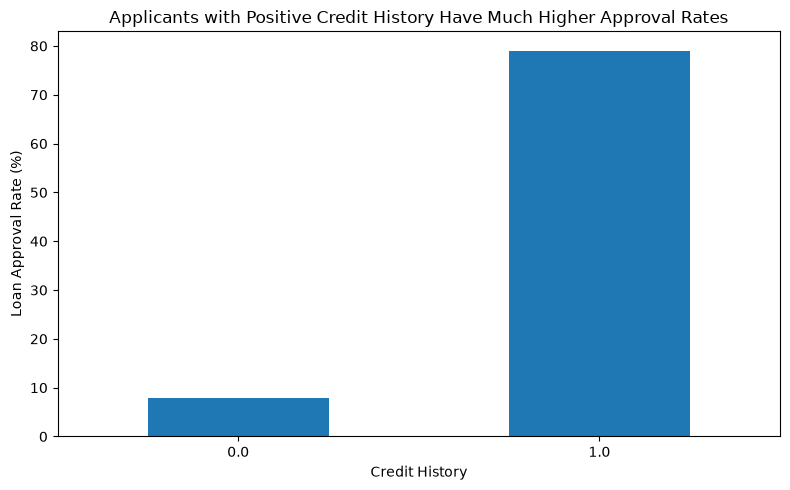

In [51]:
# Create the first visualization

plt.figure(figsize=(8, 5))

approval_by_credit.plot(kind="bar")

plt.xlabel("Credit History")
plt.ylabel("Loan Approval Rate (%)")
plt.title("Applicants with Positive Credit History Have Much Higher Approval Rates")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../reports/assignment2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# 5.2 Chart 2: Applicant Income and Loan Amount

#The second visualization examines the relationship between applicant income and requested loan amount while distinguishing between approved and rejected applications.

# Create separate groups for approved and rejected applications

approved = df_clean[df_clean["Loan_Status"] == "Y"]
rejected = df_clean[df_clean["Loan_Status"] == "N"]

print("Approved applications:", len(approved))
print("Rejected applications:", len(rejected))

Approved applications: 422
Rejected applications: 192


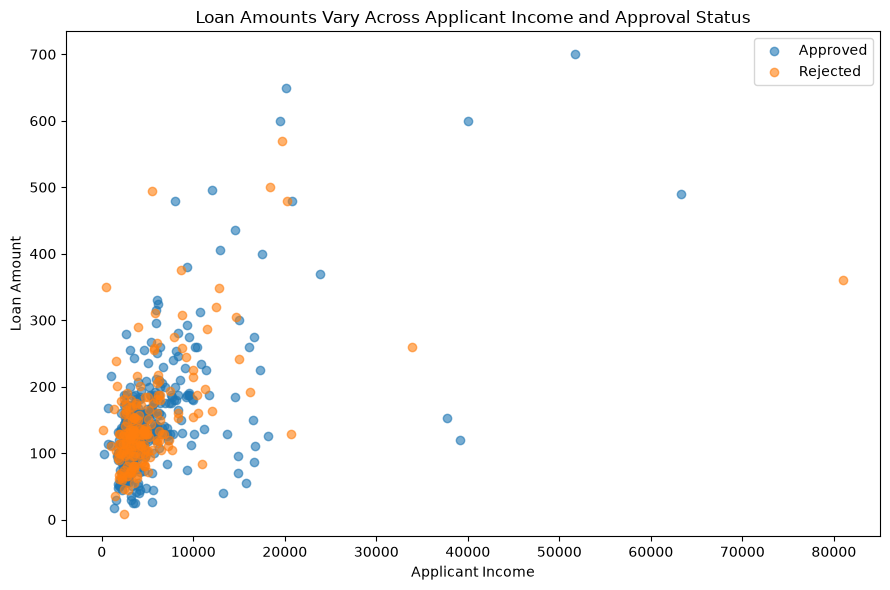

In [50]:
# Create the second visualization

plt.figure(figsize=(9, 6))

plt.scatter(
    approved["ApplicantIncome"],
    approved["LoanAmount"],
    label="Approved",
    alpha=0.6
)

plt.scatter(
    rejected["ApplicantIncome"],
    rejected["LoanAmount"],
    label="Rejected",
    alpha=0.6
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Loan Amounts Vary Across Applicant Income and Approval Status")
plt.legend()

plt.tight_layout()
plt.savefig("../reports/assignment2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

5.3 Chart 3: Average Loan Amount by Education and Approval Status

The second visualization compares the average requested loan amount across education levels and loan approval outcomes.

This helps examine whether loan amount patterns differ between approved and rejected applications and whether the pattern varies by education level.

In [46]:
# Calculate average loan amount by education and loan status

education_loan = (
    df_clean.groupby(["Education", "Loan_Status"])["LoanAmount"]
    .mean()
    .unstack()
)

education_loan

Loan_Status,N,Y
Education,,
Graduate,159.957143,150.482353
Not Graduate,122.788462,116.451220


<Figure size 900x600 with 0 Axes>

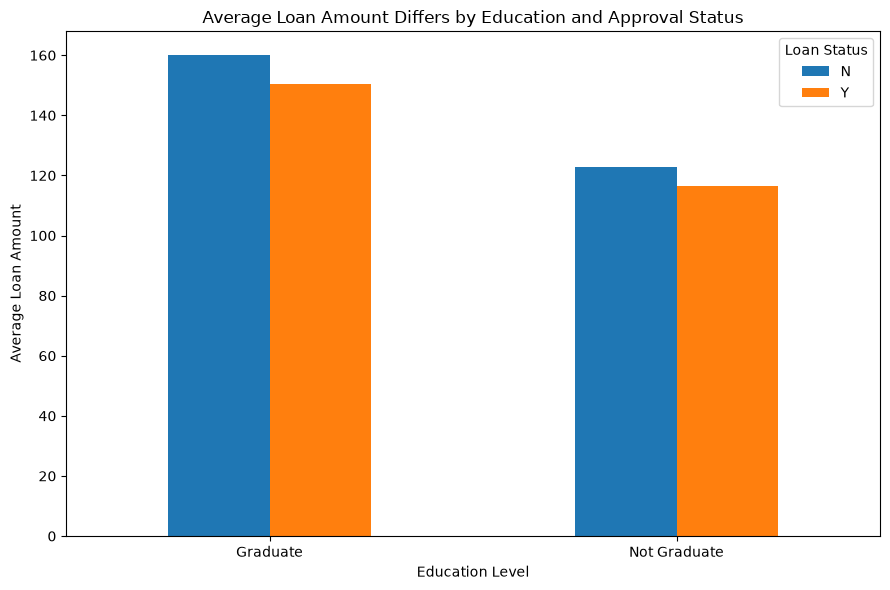

In [49]:
plt.figure(figsize=(9, 6))

education_loan.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel("Education Level")
plt.ylabel("Average Loan Amount")
plt.title("Average Loan Amount Differs by Education and Approval Status")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

plt.tight_layout()
plt.savefig("../reports/assignment2_chart3.png", dpi=150, bbox_inches="tight")
plt.show()

5.3 Additional Analysis: Applicant Income and Loan Amount

This visualization examines whether applicant income is associated with the amount of loan requested. A trendline is included to make the overall relationship easier to interpret.

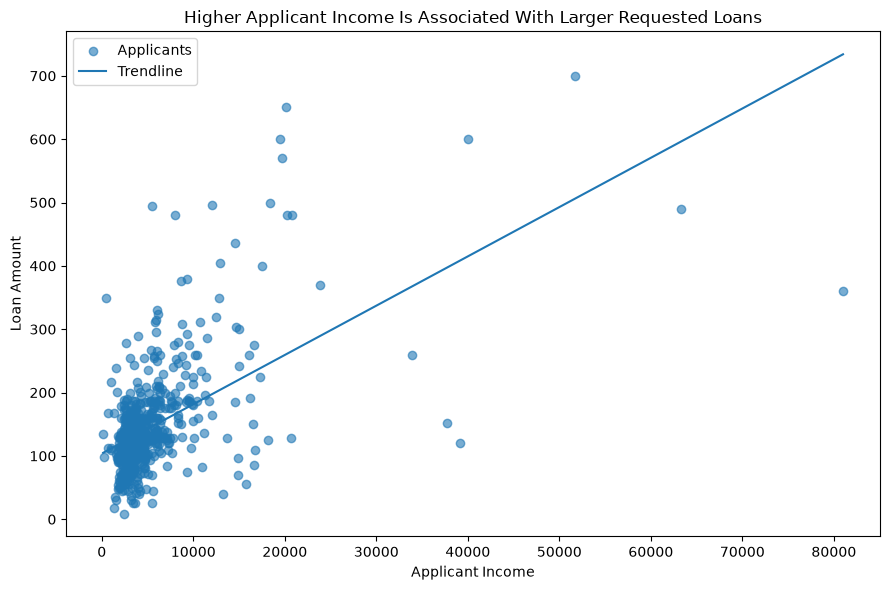

In [48]:
# Examine the relationship between applicant income and loan amount

plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["ApplicantIncome"],
    df_clean["LoanAmount"],
    alpha=0.6,
    label="Applicants"
)

# Calculate and plot a linear trendline
x = df_clean["ApplicantIncome"].to_numpy()
y = df_clean["LoanAmount"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    label="Trendline"
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Higher Applicant Income Is Associated With Larger Requested Loans")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/assignment2_chart4.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Task 6: Cleaned Dataset and Analysis Report

The cleaned and feature-engineered dataset will be saved in the `data/processed/` directory. I will then document the main question explored, the findings from the analysis, and one limitation of the dataset.

In [44]:
# Save the cleaned and feature-engineered dataset

output_path = "../data/processed/assignment2_loan_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../data/processed/assignment2_loan_cleaned.csv


In [45]:
# Verify that the processed dataset was saved correctly

processed_df = pd.read_csv(output_path)

print("Processed dataset shape:", processed_df.shape)
print("\nProcessed dataset columns:")
print(processed_df.columns.tolist())

Processed dataset shape: (614, 16)

Processed dataset columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'approval_rate', 'average_loan_amount', 'LoanAmount_Standardized']
